# Кластеризация ЕГЭ (4 если сделаны все задачи)

Рядом лежат данные с координатами точек. Везде используется Евклидово расстояние. Кластером считается набор не менее чем из 30 точек связанных друг с другом. Аномалия это точка находящаяся на расстоянии более 1 от любого кластера.

* Постройте Распределение точек
* Напишите руками DBSCAN и обработайте им все файлы
* Файл 0.xls также решите руками
* Постройте Распределение точек, отметьте принадлежность кластеров цветами
* Отметьте Аномалии отдельным цветом
* Найдите среди в каждом кластере точку расстояние от которой до всех остальных минимально
* Выведите два числа - Среднее абсцисс и ординат центроидов кластеров * 100000

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



Обработка 0.xls...

Обработка 1.xls...

Обработка 2.txt...

Обработка 3.txt...

Обработка 4.txt...

Обработка 5.txt...


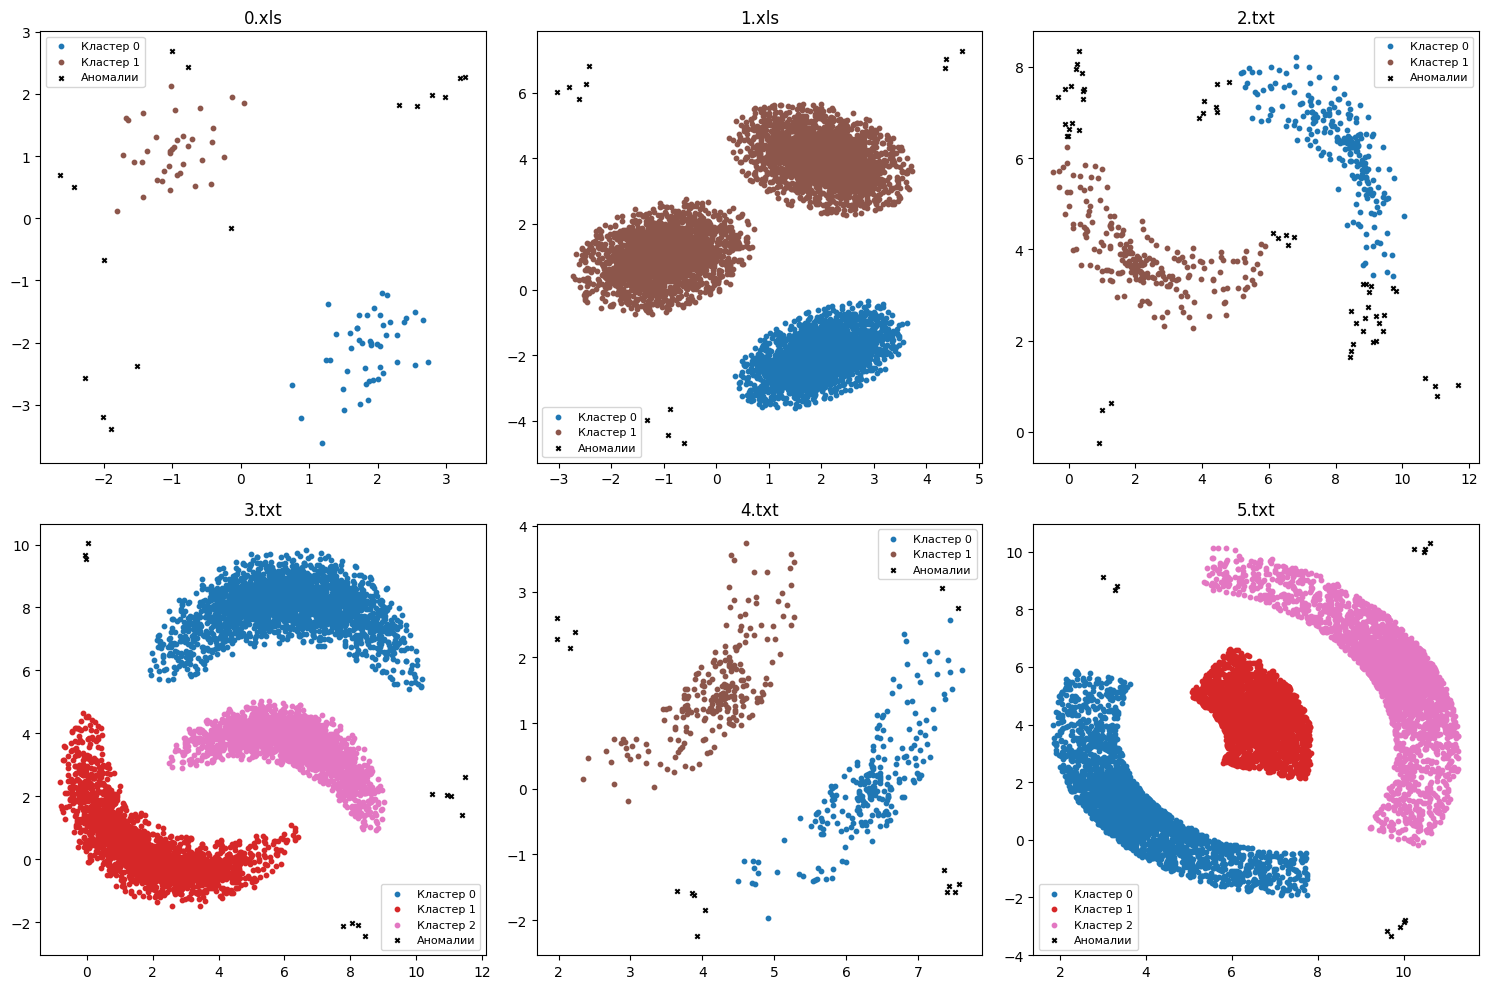


Среднее абсцисс центроидов * 100000: 415905.400372
Среднее ординат центроидов * 100000: 243346.497539


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import os

def dbscan_manual(X, eps, min_samples):
    n = len(X)
    labels = np.full(n, -1)
    visited = np.zeros(n, bool)
    cluster_id = 0

    diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]   # (n, n, 2)
    sq_dist = (diff ** 2).sum(axis=2)                  # (n, n)
    dist_matrix = np.sqrt(sq_dist)                     # (n, n)

    for i in range(n):
        if visited[i]:
            continue
        visited[i] = True

        neighbors = np.where(dist_matrix[i] <= eps)[0]

        if len(neighbors) < min_samples:
            continue

        labels[i] = cluster_id
        queue = deque(neighbors)

        while queue:
            j = queue.popleft()
            if not visited[j]:
                visited[j] = True
                j_neighbors = np.where(dist_matrix[j] <= eps)[0]
                if len(j_neighbors) >= min_samples:
                    queue.extend(j_neighbors)
            if labels[j] == -1:
                labels[j] = cluster_id

        cluster_id += 1

    return labels

file_names = ['0.xls', '1.xls', '2.txt', '3.txt', '4.txt', '5.txt']
all_centroids = []

plt.figure(figsize=(15, 10))

for idx, fname in enumerate(file_names):
    print(f"\nОбработка {fname}...")

    if fname.endswith('.xls'):
        df = pd.read_excel(fname)
    else:
        df = pd.read_csv(fname)

    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna()

    X = df.values.astype(float)

    labels = dbscan_manual(X, eps=1.0, min_samples=30)

    unique_labels = set(labels)
    unique_labels.discard(-1)
    n_clusters = len(unique_labels)

    for cl in unique_labels:
        cluster_points = X[labels == cl]
        diff_cl = cluster_points[:, np.newaxis, :] - cluster_points[np.newaxis, :, :]
        dist_mat_cl = np.sqrt((diff_cl ** 2).sum(axis=2))
        sum_dist = dist_mat_cl.sum(axis=1)
        best_idx = np.argmin(sum_dist)
        best_point = cluster_points[best_idx]
        all_centroids.append(best_point)

    plt.subplot(2, 3, idx+1)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)+1))
    for k in unique_labels:
        plt.scatter(X[labels==k, 0], X[labels==k, 1],
                    color=colors[k], label=f'Кластер {k}', s=10)
        
    plt.scatter(X[labels==-1, 0], X[labels==-1, 1],
                color='black', marker='x', label='Аномалии', s=10)
    plt.title(f'{fname}')
    plt.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

if all_centroids:
    centroids = np.array(all_centroids)
    mean_x = np.mean(centroids[:, 0]) * 100000
    mean_y = np.mean(centroids[:, 1]) * 100000
    print(f"\nСреднее абсцисс центроидов * 100000: {mean_x:.6f}")
    print(f"Среднее ординат центроидов * 100000: {mean_y:.6f}")
else:
    print("\nКластеры не найдены ни в одном файле.")

# Кластеризация (1 за каждый алгоритм на всех данных)

На предложенных распределениях данных проверьте предложенные алгоритмы. Постройте графики кластеризации для каждой пары алгоритм-данные, разные кластеры покрасьте разным цветом. Воспользуйтесь sklearn реализациями. Параметры кластеризации для разных алгоритмов подберите такие, чтобы алгоритмы можно было сравнивать (по возможности одинаковое количество кластеров и т.д.)

In [19]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice

In [20]:
from sklearn import cluster, mixture

two_means = cluster.KMeans(n_clusters=2)
dbscan = cluster.DBSCAN(eps=0.3)

ms = cluster.MeanShift()
spectral = cluster.SpectralClustering(n_clusters=2, eigen_solver='arpack', affinity='nearest_neighbors')
ward = cluster.AgglomerativeClustering(n_clusters=2, linkage='ward')

average_linkage = cluster.AgglomerativeClustering(linkage='average', metric='cityblock', n_clusters=2)
optics = cluster.OPTICS(min_samples=20, xi=0.05, min_cluster_size=0.1)
gmm = mixture.GaussianMixture(n_components=2)

clustering_algorithms = (
    ('KMeans', two_means),
    ('DBSCAN', dbscan),
    ('MeanShift', ms),
    ('Spectral\nClustering', spectral),
    ('Ward', ward),
    ('Agglomerative\nClustering', average_linkage),
    ('OPTICS', optics),
    ('Gaussian\nMixture', gmm),
)

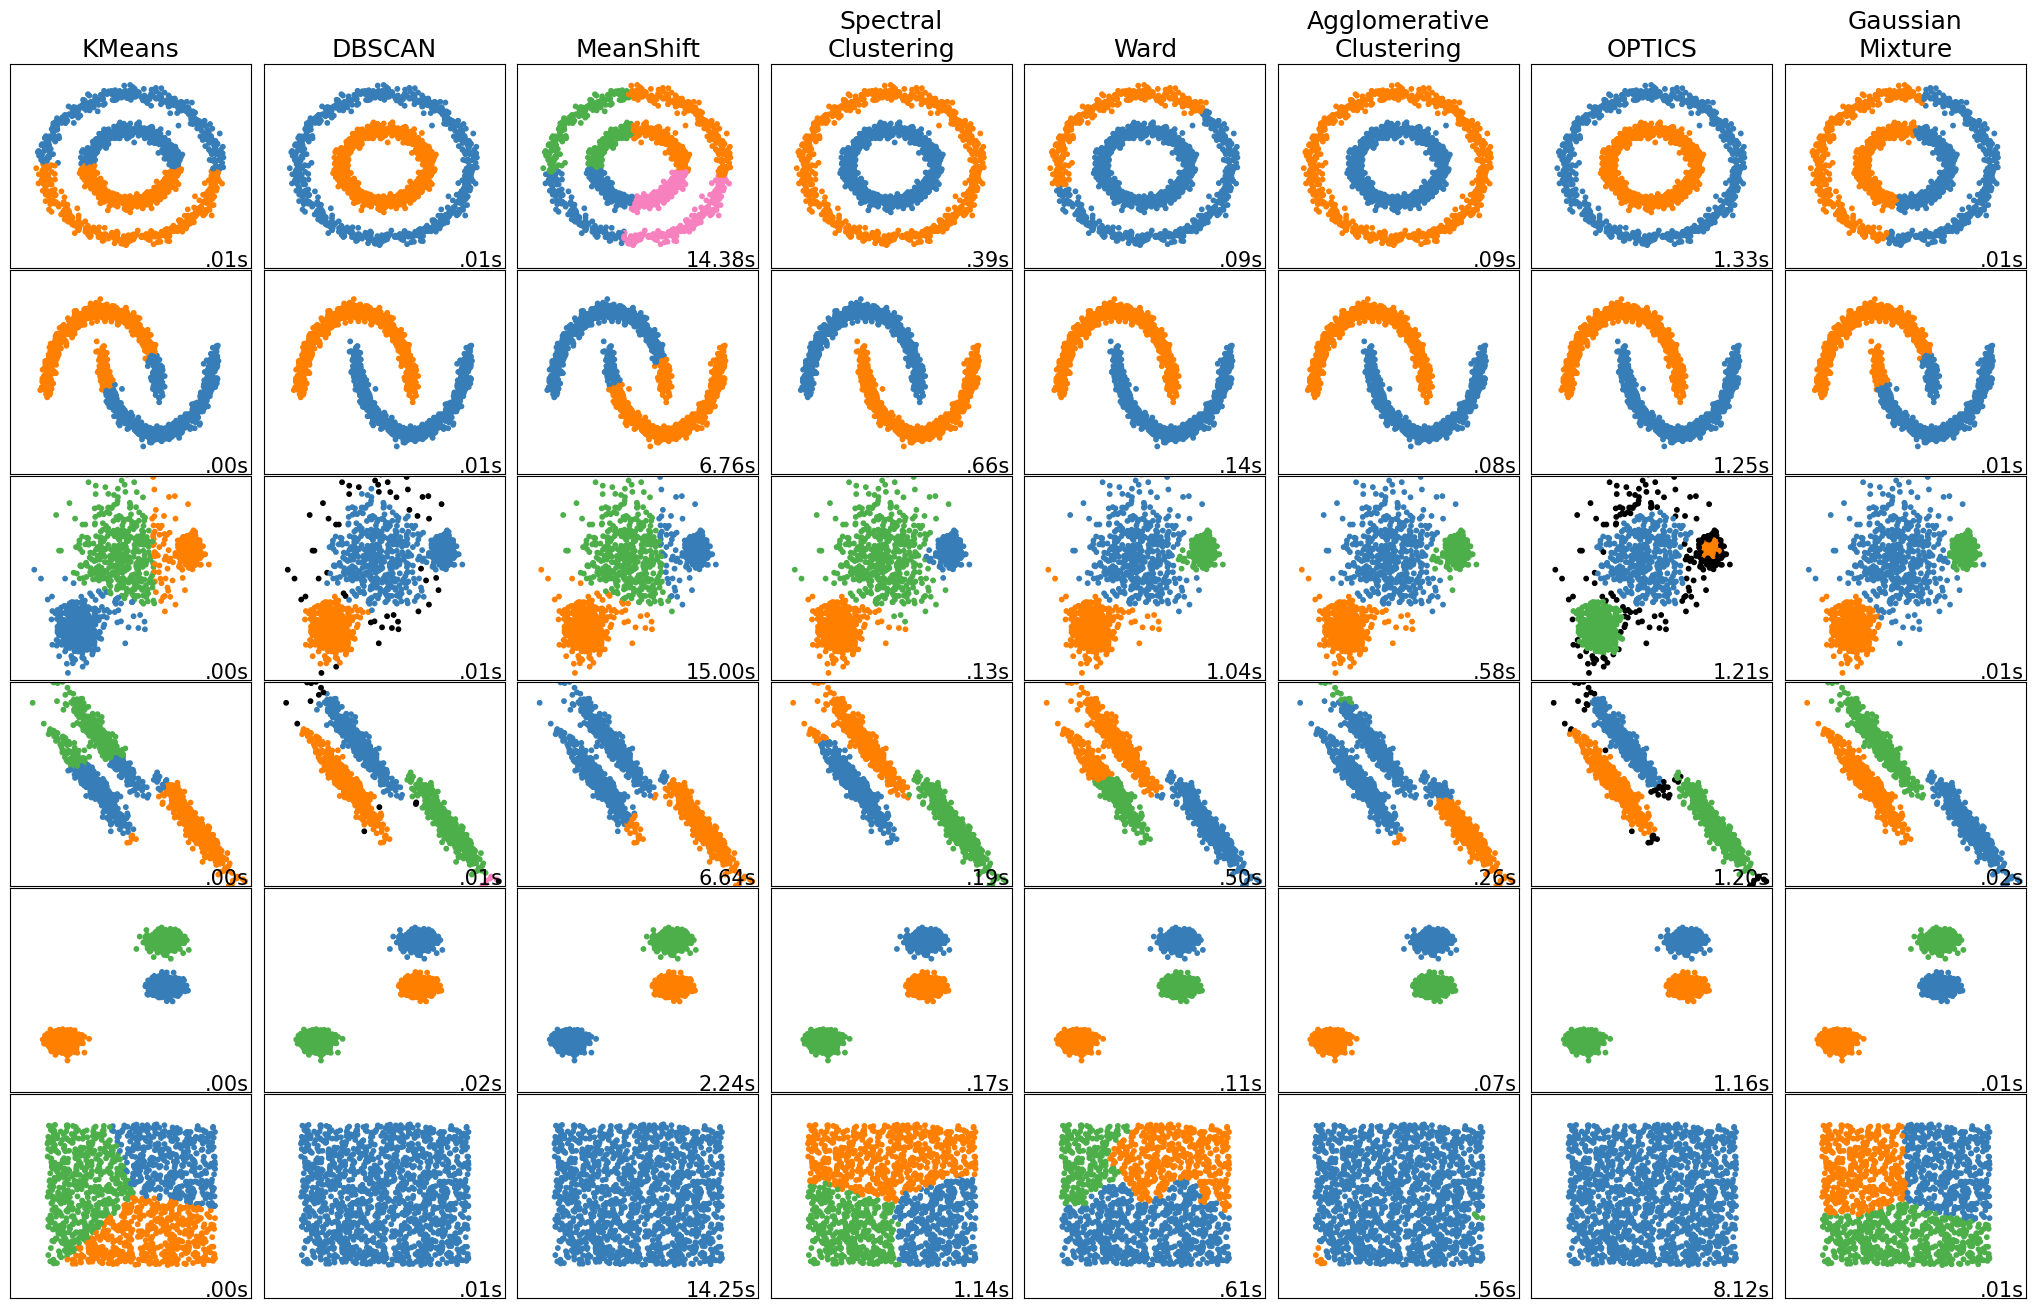

In [21]:
np.random.seed(0)

n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
no_structure = np.random.rand(n_samples, 2), None

random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)

plt.figure(figsize=(9 * 2 + 3, 13))
plt.subplots_adjust(
    left=0.02, right=0.98, bottom=0.001, top=0.95, wspace=0.05, hspace=0.01
)

plot_num = 1

default_base = {
    "quantile": 0.3,
    "eps": 0.3,
    "damping": 0.9,
    "preference": -200,
    "n_neighbors": 10,
    "n_clusters": 3,
    "min_samples": 20,
    "xi": 0.05,
    "min_cluster_size": 0.1,
}

dataset_list = [
    (
        noisy_circles,
        {
            "damping": 0.77,
            "preference": -240,
            "quantile": 0.2,
            "n_clusters": 2,
            "min_samples": 20,
            "xi": 0.25,
        },
    ),
    (noisy_moons, {"damping": 0.75, "preference": -220, "n_clusters": 2}),
    (
        varied,
        {
            "eps": 0.18,
            "n_neighbors": 2,
            "min_samples": 5,
            "xi": 0.035,
            "min_cluster_size": 0.2,
        },
    ),
    (
        aniso,
        {
            "eps": 0.15,
            "n_neighbors": 2,
            "min_samples": 20,
            "xi": 0.1,
            "min_cluster_size": 0.2,
        },
    ),
    (blobs, {}),
    (no_structure, {}),
]

for i_dataset, (dataset, algo_params) in enumerate(dataset_list):
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset

    X = StandardScaler().fit_transform(X)

    bandwidth = cluster.estimate_bandwidth(X, quantile=params["quantile"])

    connectivity = kneighbors_graph(
        X, n_neighbors=params["n_neighbors"], include_self=False
    )
    connectivity = 0.5 * (connectivity + connectivity.T)

    two_means = cluster.KMeans(n_clusters=params["n_clusters"])
    dbscan = cluster.DBSCAN(eps=params["eps"])
    ms = cluster.MeanShift(bandwidth=bandwidth)
    spectral = cluster.SpectralClustering(
        n_clusters=params["n_clusters"],
        eigen_solver='arpack',
        affinity='nearest_neighbors'
    )
    ward = cluster.AgglomerativeClustering(
        n_clusters=params["n_clusters"],
        connectivity=connectivity,
        linkage='ward'
    )
    average_linkage = cluster.AgglomerativeClustering(
        linkage='average',
        metric='cityblock',
        n_clusters=params["n_clusters"],
        connectivity=connectivity
    )
    optics = cluster.OPTICS(
        min_samples=params["min_samples"],
        xi=params["xi"],
        min_cluster_size=params["min_cluster_size"]
    )
    gmm = mixture.GaussianMixture(
        n_components=params["n_clusters"],
        covariance_type='full'
    )

    clustering_algorithms = (
        ('KMeans', two_means),
        ('DBSCAN', dbscan),
        ('MeanShift', ms),
        ('Spectral\nClustering', spectral),
        ('Ward', ward),
        ('Agglomerative\nClustering', average_linkage),
        ('OPTICS', optics),
        ('Gaussian\nMixture', gmm),
    )

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="the number of connected components of the "
                "connectivity matrix is [0-9]{1,2}"
                " > 1. Completing it to avoid stopping the tree early.",
                category=UserWarning,
            )
            warnings.filterwarnings(
                "ignore",
                message="Graph is not fully connected, spectral embedding"
                " may not work as expected.",
                category=UserWarning,
            )
            algorithm.fit(X)

        t1 = time.time()
        if hasattr(algorithm, 'labels_'):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        plt.subplot(len(dataset_list), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=18)

        colors = np.array(
            list(islice(cycle(['#377eb8', '#ff7f00', '#4daf4a',
                               '#f781bf', '#a65628', '#984ea3',
                               '#999999', '#e41a1c', '#dede00']),
                        int(max(y_pred) + 1)))
        )

        colors = np.append(colors, ["#000000"])
        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])
        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plt.text(
            0.99,
            0.01,
            ("%.2fs" % (t1 - t0)).lstrip("0"),
            transform=plt.gca().transAxes,
            size=15,
            horizontalalignment="right",
        )
        plot_num += 1

plt.show()